<a href="https://colab.research.google.com/github/tsvlgd/MLE/blob/main/advanced_ml/03-tensorflow-keras/architecture/cnn_LeNet_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt

In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Is GPU available? ", tf.test.is_gpu_available())

Num GPUs Available:  1
Is GPU available?  True


In [4]:
# Load and preprocess MNIST data
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255.0

# One-hot encode labels
train_labels = keras.utils.to_categorical(train_labels, 10)
test_labels = keras.utils.to_categorical(test_labels, 10)


In [8]:
# LeNet-5 in Keras (Original Architecture)

# Define LeNet-5
class LeNet(models.Sequential):
    def __init__(self, input_shape, nb_classes):
        super().__init__()

        self.add(layers.Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='tanh', input_shape=input_shape, padding="same"))
        self.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(1, 1), padding='valid'))
        self.add(layers.Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'))
        self.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
        self.add(layers.Conv2D(120, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'))
        self.add(layers.Flatten())
        self.add(layers.Dense(84, activation='tanh'))
        self.add(layers.Dense(nb_classes, activation='softmax'))

        self.compile(loss=tf.keras.losses.categorical_crossentropy,
                     optimizer='SGD',
                     metrics=['accuracy'])

In [5]:
# Build and train the model
model = LeNet((28, 28, 1), 10)
model.summary()

history = model.fit(train_images, train_labels,
                    batch_size=128,
                    epochs=10,
                    validation_data=(test_images, test_labels))

Model: "le_net_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 27, 27, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 23, 23, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 11, 11, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5880)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 84)             │       494,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,546 (2.08 MB)

 Trainable params: 545,546 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7117 - loss: 1.1132 - val_accuracy: 0.9071 - val_loss: 0.3435
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9066 - loss: 0.3354 - val_accuracy: 0.9229 - val_loss: 0.2682
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9244 - loss: 0.2639 - val_accuracy: 0.9345 - val_loss: 0.2275
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9337 - loss: 0.2317 - val_accuracy: 0.9420 - val_loss: 0.2001
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9413 - loss: 0.2058 - val_accuracy: 0.9481 - val_loss: 0.1793
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9502 - loss: 0.1775 - val_accuracy: 0.9528 - val_loss: 0.1636
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9531 - loss: 0.1619 - val_accuracy: 0.9551 - val_loss: 0.1513
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9566 - loss: 0.1525 - val_accuracy: 0.

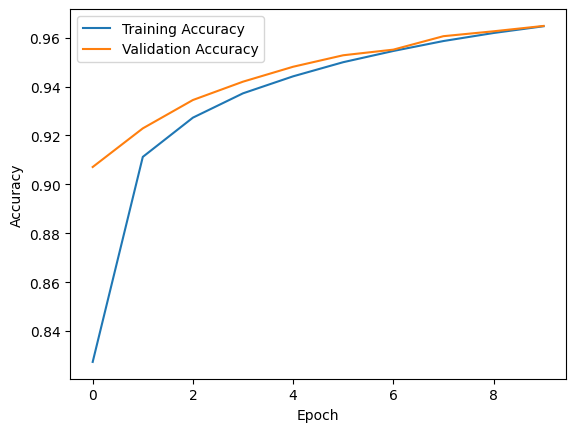

313/313 - 1s - 3ms/step - accuracy: 0.9648 - loss: 0.1213

Test accuracy: 0.9648


In [7]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")